In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_perexp_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

FIBERSTATUS 482229 89529 0.1565854784716611
No data 482229 0 0.0
LRG mask 433621 48608 0.10079858324571936
Remove QSO targets 419401 14220 0.032793614700395046


In [4]:
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_1x_depth_lrg.fits'))
cat_1x['EFFTIME_ELG'] = 8.60 * cat_1x['TSNR2_ELG']
cat_1x['EFFTIME_LRG'] = 12.15 * cat_1x['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat_1x['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat_1x['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat_1x = cat_1x[~mask_bad]
# print(len(cat_1x), len(np.unique(cat_1x['TARGETID'])))

FIBERSTATUS 27179 4874 0.15206064954918416
No data 27179 0 0.0
LRG mask 25072 2107 0.07752308767798669
Remove QSO targets 24557 515 0.020540842373962986


In [5]:
columns = list(np.intersect1d(cat.colnames, cat_1x.colnames))
cat = cat[columns]
cat_1x = cat_1x[columns]

cat = vstack([cat, cat_1x])

In [6]:
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth
min_depth = 3000.
mask = deep['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(deep['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# deep = deep[~mask_bad]
# print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

mask_star = (deep['SPECTYPE']=='STAR') | (deep['Z']<0.0003)
print('Remove stars', np.sum(mask_star), np.sum(~mask_star), np.sum(mask_star)/len(mask_star))
deep = deep[~mask_star]
print(len(deep))

deep_columns_old = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'DELTACHI2', 'EFFTIME_LRG', 'EFFTIME_ELG']
deep_columns_new = ['TARGETID', 'Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_LRG_deep', 'EFFTIME_ELG_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

cat = join(cat, deep[deep_columns_new], keys='TARGETID')

COADD_FIBERSTATUS 46403 8832 0.15989861500859961
No data 45392 1011 0.021787384436351098
LRG mask 41301 4091 0.09012601339443074
Remove QSO targets 39607 1694 0.041015956030120336
Min depth 30657 8950 0.7740298432095337
30607 30607
Remove stars 251 30356 0.008200738393178031
30356


In [7]:
main = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/main_cumulative_lrg.fits'))
main['EFFTIME_ELG'] = 8.60 * main['TSNR2_ELG']
main['EFFTIME_LRG'] = 12.15 * main['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = main['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove "no data" fibers
mask = main['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Apply LRG mask
mask = main['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove QSO targets
mask = main['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = main['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# main = main[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(main['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# main = main[~mask_bad]
# print(len(main), len(np.unique(main['TARGETID'])))

mask_star = (main['SPECTYPE']=='STAR') | (main['Z']<0.0003)
print('Remove stars', np.sum(mask_star), np.sum(~mask_star), np.sum(mask_star)/len(mask_star))
main = main[~mask_star]
print(len(main))

FIBERSTATUS 340944 5119 0.014792104327824702
No data 340944 0 0.0
LRG mask 306665 34279 0.10054143789009339
Remove QSO targets 301954 4711 0.015362040011087017
Remove stars 1397 300557 0.004626532518198136
300557


In [8]:
mask = cat['EFFTIME_LRG']>800
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]
print(len(cat))

Min depth 66340 308739 0.17686940617843175
66340


In [9]:
mask = main['EFFTIME_LRG']>800
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
main = main[mask]
print(len(main))

Min depth 293386 7171 0.9761409649417582
293386


In [10]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
main['zfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_Z']) - 1.211 * main['EBV']

---------

In [11]:
# Catastrophic redshift failures
zdiff_threshold = 0.0033
mask_fail = np.abs((cat['Z'] - cat['Z_deep'])/(1 + cat['Z_deep'])) > zdiff_threshold
# Also reject objects with ZWARN!=0 or z>1.4 in the deep coadds
mask_deep_fail = (cat['ZWARN_deep']!=0) | (cat['Z_deep']>1.4)
# mask_deep_fail = (cat['ZWARN_deep']!=0) | (cat['Z_deep']>1.4) | (cat['DELTACHI2_deep']<25)
mask_fail |= mask_deep_fail
print('All SV LRGs:')
print('Catastrophic failure rate: {:.2f}% ({}/{})'.format(100*np.sum(mask_fail)/len(mask_fail), np.sum(mask_fail), len(mask_fail)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Catastrophic failure rate: {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

All SV LRGs:
Catastrophic failure rate: 4.35% (2883/66340)

Main LRGs in SV:
Catastrophic failure rate: 1.55% (288/18631)


In [12]:
# DELTACHI2 cut
q0 = cat['ZWARN']==0
q0 &= cat['Z']<1.4
q0 &= cat['DELTACHI2']>12.5

# Custom DELTACHI2 vs redshift cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
q = cat['ZWARN']==0
q &= cat['Z']<1.4
q &= (~mask_remove)

# Custom DELTACHI2 vs zfiber cut
q1 = cat['DELTACHI2'] > 10**(-(cat['zfibermag']-20)*0.4*2 + 2.17)
q1 |= cat['DELTACHI2'] > 10**(-(cat['zfibermag']-20)*0.4 + 2.1)
q1 &= cat['ZWARN']==0
q1 &= cat['Z']<1.4

In [13]:
print('########### DELTACHI2 cut ###########')
print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q0)/len(q0)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q0) & mask_fail)/np.sum(~q0), np.sum((~q0) & mask_fail), np.sum(~q0)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q0) & mask_fail)/np.sum(q0), np.sum(q0 & mask_fail), np.sum(q0)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q0))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q0) & mask_fail)/np.sum(mask & (~q0)), np.sum(mask & (~q0) & mask_fail), np.sum(mask & (~q0))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q0 & mask_fail)/np.sum(mask & q0), np.sum(mask & q0 & mask_fail), np.sum(mask & q0)))

########### DELTACHI2 cut ###########
SV LRGs:
Removed fraction: 7.00%
Catastrophic failure rate of removed objects: 51.51% (2391/4642)
Catastrophic failure rate of remaining objects: 0.80% (492/61698)

Main LRGs in SV:
Removed fraction: 1.70%
Catastrophic failure rate of removed objects: 67.51% (214/317)
Catastrophic failure rate of remaining objects: 0.40% (74/18314)


In [14]:
print('########### DELTACHI2 vs redshift cut ###########')
print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q)/len(q)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q) & mask_fail)/np.sum(~q), np.sum((~q) & mask_fail), np.sum(~q)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q) & mask_fail)/np.sum(q), np.sum(q & mask_fail), np.sum(q)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q) & mask_fail)/np.sum(mask & (~q)), np.sum(mask & (~q) & mask_fail), np.sum(mask & (~q))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q & mask_fail)/np.sum(mask & q), np.sum(mask & q & mask_fail), np.sum(mask & q)))

########### DELTACHI2 vs redshift cut ###########
SV LRGs:
Removed fraction: 6.28%
Catastrophic failure rate of removed objects: 57.58% (2397/4163)
Catastrophic failure rate of remaining objects: 0.78% (486/62177)

Main LRGs in SV:
Removed fraction: 1.65%
Catastrophic failure rate of removed objects: 72.64% (223/307)
Catastrophic failure rate of remaining objects: 0.35% (65/18324)


In [15]:
print('########### DELTACHI2 vs zfiber cut ###########')
print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q1)/len(q1)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q1) & mask_fail)/np.sum(~q1), np.sum((~q1) & mask_fail), np.sum(~q1)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q1) & mask_fail)/np.sum(q1), np.sum(q1 & mask_fail), np.sum(q1)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q1))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q1) & mask_fail)/np.sum(mask & (~q1)), np.sum(mask & (~q1) & mask_fail), np.sum(mask & (~q1))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q1 & mask_fail)/np.sum(mask & q1), np.sum(mask & q1 & mask_fail), np.sum(mask & q1)))

########### DELTACHI2 vs zfiber cut ###########
SV LRGs:
Removed fraction: 5.70%
Catastrophic failure rate of removed objects: 58.54% (2214/3782)
Catastrophic failure rate of remaining objects: 1.07% (669/62558)

Main LRGs in SV:
Removed fraction: 1.66%
Catastrophic failure rate of removed objects: 70.23% (217/309)
Catastrophic failure rate of remaining objects: 0.39% (71/18322)


In [16]:
q2 = q & q1

print('########### DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut ###########')
print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q2)/len(q2)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q2) & mask_fail)/np.sum(~q2), np.sum((~q2) & mask_fail), np.sum(~q2)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q2) & mask_fail)/np.sum(q2), np.sum(q2 & mask_fail), np.sum(q2)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q2))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q2) & mask_fail)/np.sum(mask & (~q2)), np.sum(mask & (~q2) & mask_fail), np.sum(mask & (~q2))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q2 & mask_fail)/np.sum(mask & q2), np.sum(mask & q2 & mask_fail), np.sum(mask & q2)))

########### DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut ###########
SV LRGs:
Removed fraction: 6.37%
Catastrophic failure rate of removed objects: 57.06% (2413/4229)
Catastrophic failure rate of remaining objects: 0.76% (470/62111)

Main LRGs in SV:
Removed fraction: 1.81%
Catastrophic failure rate of removed objects: 68.84% (232/337)
Catastrophic failure rate of remaining objects: 0.31% (56/18294)


In [17]:
# DELTACHI2 cut
mq0 = main['ZWARN']==0
mq0 &= main['Z']<1.4
mq0 &= main['DELTACHI2']>12.5

# Custom DELTACHI2 vs redshift cut
d = (10**(3 - 3.5*main['Z']))
mask_remove = (d>30) & (main['DELTACHI2']<30)
mask_remove |= (d<30) & (main['DELTACHI2']<d)
mask_remove |= (main['DELTACHI2']<10)
mq = main['ZWARN']==0
mq &= main['Z']<1.4
mq &= (~mask_remove)

# Custom DELTACHI2 vs zfiber cut
mq1 = main['DELTACHI2'] > 10**(-(main['zfibermag']-20)*0.4*2 + 2.17)
mq1 |= main['DELTACHI2'] > 10**(-(main['zfibermag']-20)*0.4 + 2.1)
mq1 &= main['ZWARN']==0
mq1 &= main['Z']<1.4

# DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut
mq2 = mq & mq1

In [18]:
print('DELTACHI2 cut:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq0)/len(mq0), np.sum(~mq0), len(mq0)))
print()

print('DELTACHI2 vs redshift cut:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq)/len(mq), np.sum(~mq), len(mq)))
print()

print('DELTACHI2 vs zfiber cut:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq1)/len(mq1), np.sum(~mq1), len(mq1)))
print()

print('DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq2)/len(mq2), np.sum(~mq2), len(mq2)))
print()

DELTACHI2 cut:
Removed fraction: 2.09% (6136/293386)

DELTACHI2 vs redshift cut:
Removed fraction: 2.08% (6090/293386)

DELTACHI2 vs zfiber cut:
Removed fraction: 2.08% (6109/293386)

DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut:
Removed fraction: 2.30% (6752/293386)



-------------

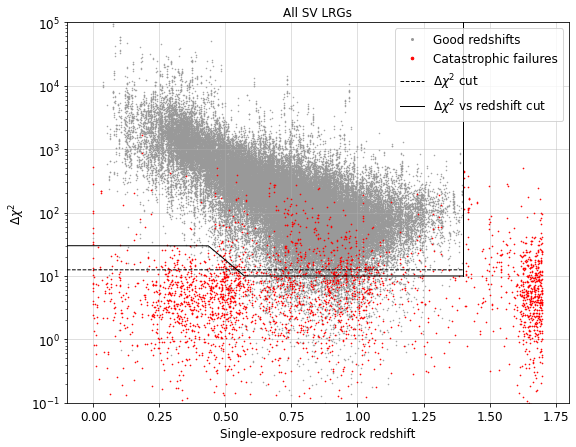

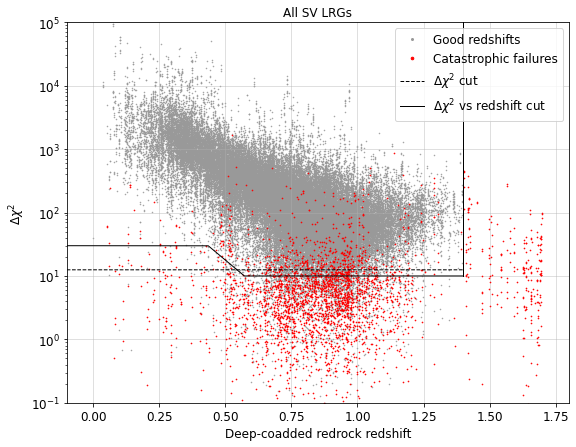

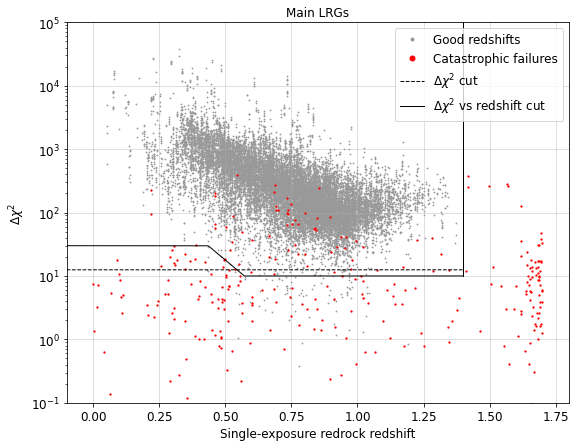

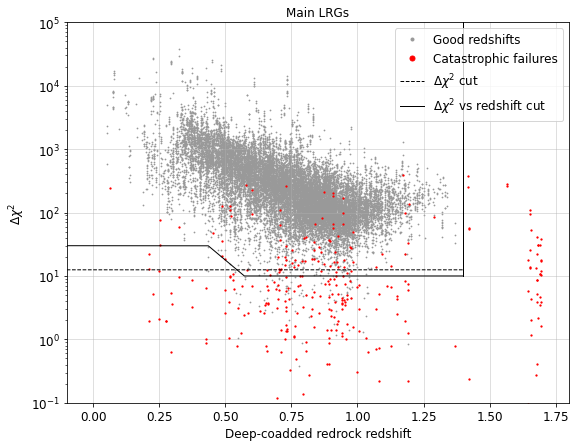

In [19]:
x = np.linspace(-1, 1.4, 10000)
y = np.ones_like(x)
y = (10**(3 - 3.5*x))
y[y<10] = 10
y[y>30] = 30
y1 = np.linspace(10, 1e6)
x1 = np.ones_like(y1) * 1.4
x0 = np.linspace(-1, 1.4, 10000)
y0 = 12.5 * np.ones_like(x0)

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1.3, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x0, y0, color='k', lw=1, ls='--', label='$\Delta \chi^2$ cut')
plt.plot(x, y, color='k', lw=1, label='$\Delta \chi^2$ vs redshift cut')
plt.plot(x1, y1, color='k', lw=1)
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.title('All SV LRGs')
plt.show()

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z_deep'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1.3, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x0, y0, color='k', lw=1, ls='--', label='$\Delta \chi^2$ cut')
plt.plot(x, y, color='k', lw=1, label='$\Delta \chi^2$ vs redshift cut')
plt.plot(x1, y1, color='k', lw=1)
plt.yscale('log')
plt.xlabel('Deep-coadded redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.title('All SV LRGs')
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=2.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x0, y0, color='k', lw=1, ls='--', label='$\Delta \chi^2$ cut')
plt.plot(x, y, color='k', lw=1, label='$\Delta \chi^2$ vs redshift cut')
plt.plot(x1, y1, color='k', lw=1)
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.title('Main LRGs')
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z_deep'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=2.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x0, y0, color='k', lw=1, ls='--', label='$\Delta \chi^2$ cut')
plt.plot(x, y, color='k', lw=1, label='$\Delta \chi^2$ vs redshift cut')
plt.plot(x1, y1, color='k', lw=1)
plt.yscale('log')
plt.xlabel('Deep-coadded redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.title('Main LRGs')
plt.show()

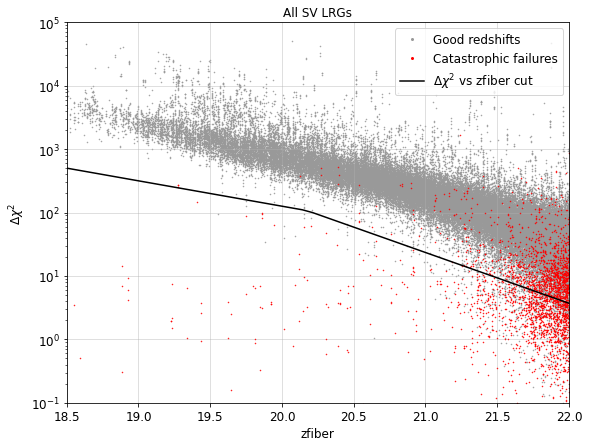

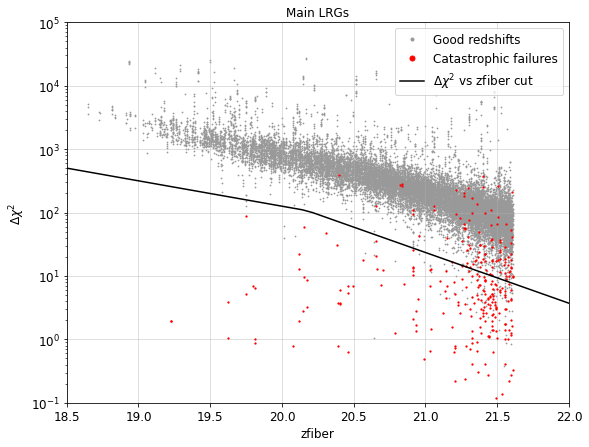

In [20]:
x = np.linspace(18.5, 22)
y1 = 10**(-(x-20)*0.4*2 + 2.17)  # sky dominated
y2 = 10**(-(x-20)*0.4 + 2.1)  # source dominated
y = np.minimum(y1, y2)

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', label='$\Delta \chi^2$ vs zfiber cut')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('$\Delta \chi^2$')
plt.axis([18.5, 22., .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.title('All SV LRGs')
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=2.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', label='$\Delta \chi^2$ vs zfiber cut')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('$\Delta \chi^2$')
plt.axis([18.5, 22., .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.title('Main LRGs')
plt.show()